In [5]:
import numpy as np

In [ ]:
from matplotlib import pyplot as plt
from nbodykit.lab import *

In [27]:
snapnum=40
tng_dir = f"/cosma7/data/dp004/dc-zhan5/TNG/snap{snapnum}/SubhaloFlag_all/mvir"
tng_data1 = np.loadtxt(f"{tng_dir}/sfr-halomass_central.txt")

mhalo_tng1 = tng_data1[:,0]
pos_tng1 = tng_data1[:,1:4]
sfr_tng1 = tng_data1[:,4]


In [34]:
sfr_lin = 10**sfr_tng1

In [48]:
boxsize= 205
Nmesh = 100
nhalo = len(sfr_tng1)


halocat = np.empty(nhalo, dtype=[("Position", ("f8", 3)), ("I_nu", "f8"), ("Mass", "f8")])


halocat["I_nu"] = sfr_lin+1
halocat["Position"] = np.array(pos_tng1)

ps_dict = {
    "Nhalo": nhalo,
    "halocat": halocat
}
arraycat = ArrayCatalog(ps_dict["halocat"])
weight="I_nu"
mesh = arraycat.to_mesh(resampler="nearest", BoxSize=boxsize, Nmesh=Nmesh, weight=weight)
        


In [49]:
print("Linear min", min(sfr_lin))
print("Linear max", max(sfr_lin))
print("Log min", min(np.log10(sfr_lin)))
print("Log max", max(np.log10(sfr_lin)))
print("Log(SFR+1) min", min(np.log10(sfr_lin+1)))
print("Log(SFR+1) max", max(np.log10(sfr_lin+1)))
new_mean = np.mean(np.log10(sfr_lin+1))
print("Log(SFR+1) mean", new_mean)

Linear min 0.000688419240753593
Linear max 1150.7879348774693
Log min -3.162147
Log max 3.0609953
Log(SFR+1) min 0.0002988738140527665
Log(SFR+1) max 3.0613725249287524
Log(SFR+1) mean 0.09899637715414193


Min is brought closer to max 

Adding 1 affects low values a lot more than high values

In [51]:
def filter(k, v):
    transformed_v = 1 + (np.log10(1+v)/new_mean)
    return transformed_v # divide the mesh by k^2

# apply the filter and get a new mesh
filtered_mesh = mesh.apply(filter, mode='real', kind='index')

# get the filtered RealField object
filtered_rfield = filtered_mesh.paint(mode='real')
rfield = mesh.paint(mode='real')


print("head of original RealField = ",  rfield[:10,0,0])
print("head of filtered Realfield = ",  filtered_rfield[:10,0,0])

head of original RealField =  [10.242403    0.6818244   0.          0.          0.          1.5672693
  1.0001563   0.51506764  5.4411836   0.        ]
head of filtered Realfield =  [11.615128   3.2806962  1.         1.         1.         5.136226
  4.0411615  2.8226123  9.171669   1.       ]


In [18]:
print(rfield[0])

[[1.4846383  1.850994   2.5221388  ... 3.7137015  2.1020277  0.73612165]
 [1.9847273  3.2587507  3.1589658  ... 0.68579984 1.1463627  1.4851815 ]
 [0.38857275 1.9760283  2.4237437  ... 0.00587357 0.08912522 0.24764706]
 ...
 [0.00721688 0.19966407 0.3812575  ... 0.23456311 0.19976097 0.10529557]
 [0.02618171 0.08308057 0.7127238  ... 1.5408564  0.5131729  0.5997105 ]
 [0.44717842 0.37191805 0.5409602  ... 1.895201   1.2964563  0.755784  ]]


In [19]:
new = np.log10(rfield+1)
print(new[0])

[[0.39526317 0.45499632 0.54680645 ... 0.6733621  0.49164566 0.23958015]
 [0.47490466 0.62928224 0.61898535 ... 0.22680603 0.33170313 0.3953581 ]
 [0.14256862 0.47363707 0.53450125 ... 0.00254339 0.03707779 0.09609175]
 ...
 [0.00312302 0.07905967 0.14027467 ... 0.0915133  0.07909472 0.04347842]
 [0.01122426 0.03466075 0.23368731 ... 0.40498012 0.17988855 0.20404139]
 [0.16052206 0.13732818 0.18779144 ... 0.4616787  0.36105818 0.2444711 ]]


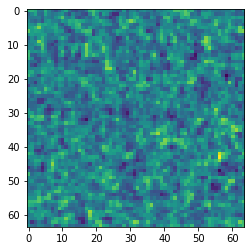

In [20]:
density = mesh.preview(Nmesh=64, axes=(0,1))
plt.imshow(density)

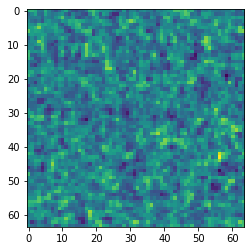

In [21]:
density = filtered_mesh.preview(Nmesh=64, axes=(0,1))
plt.imshow(density)